# Point-in-polygon queries

Finding out if a certain point is located inside or outside of an area, or finding out if a line intersects with another line or polygon are fundamental geospatial operations that are often used e.g. to select data based on location. Such spatial queries are one of the typical first steps of the workflow when doing spatial analysis. Performing a spatial join (will be introduced later) between two spatial datasets is one of the most typical applications where Point in Polygon (PIP) query is used.

Computationally, detecting if a point is inside a polygon is most commonly done using a specific formula called Ray Casting algorithm. Luckily, we do not need to create such a function ourselves for conducting the Point in Polygon (PIP) query. Instead, we can take advantage of Shapely’s binary predicates that can evaluate the topolocical relationships between geographical objects, such as the PIP as we’re interested here.

## Query on shapely geometries

There are basically two ways of conducting PIP in Shapely:

1. using a function called within() that checks if a point is within a polygon
2. using a function called contains() that checks if a polygon contains a point

In [2]:
import shapely.geometry
point1 = shapely.geometry.Point(24.952242, 60.1696017)
point2 = shapely.geometry.Point(24.976567, 60.1612500)

polygon = shapely.geometry.Polygon(
    [
        (24.950899, 60.169158),
        (24.953492, 60.169158),
        (24.953510, 60.170104),
        (24.950958, 60.169990)
    ]
)

In [3]:
point1.within(polygon)

True

In [4]:
point2.within(polygon)

False

In [9]:
polygon.contains(point1)

True

In [ ]:
polygon.contains(point2)

## Point-in-polygon queries on geopandas

In [11]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"

In [12]:
import geopandas

city_districts = geopandas.read_file(
    DATA_DIRECTORY / "helsinki_city_districts" / "helsinki_city_districts_2021.gpkg"
)
city_districts.head()

,name,geometry
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,..."
1,Läntinen,"POLYGON ((24.8314 60.25406, 24.83168 60.25321,..."
2,Keskinen,"POLYGON ((24.93345 60.18317, 24.93502 60.18005..."
3,Pohjoinen,"POLYGON ((24.90081 60.23526, 24.89944 60.235, ..."
4,Koillinen,"POLYGON ((24.97163 60.24253, 24.97163 60.24246..."


<Axes: >

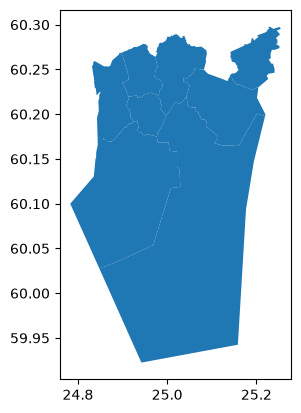

In [13]:
city_districts.plot()

In [14]:
southern_district = city_districts[city_districts.name == "Eteläinen"]
southern_district

,name,geometry
0,Eteläinen,"POLYGON ((24.7828 60.09996, 24.80437 60.07607,..."


In [15]:
addresses = geopandas.read_file(DATA_DIRECTORY / "addresses.gpkg")

/home/faustino/miniconda3/envs/autogis/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'addresses.gpkg': 'addresses' (default), 'addresses_with_population_data'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

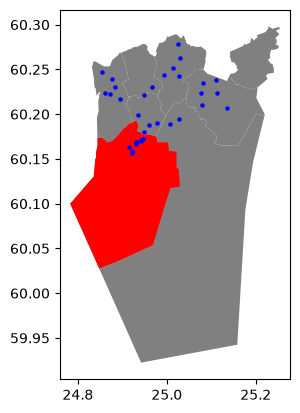

In [16]:
axes = city_districts.plot(facecolor="grey")
southern_district.plot(ax=axes, facecolor="red")
addresses.plot(ax=axes, color="blue", markersize=5)

In [17]:
addresses.within(southern_district.at[0, 'geometry'])

0      True
1      True
2      True
3     False
4      True
5     False
6     False
7     False
8     False
9     False
10     True
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30     True
31     True
32     True
33     True
dtype: bool

In [18]:
addresses_in_the_southern_district = addresses[
    addresses.within(southern_district.at[0, "geometry"])
]
addresses_in_the_southern_district

,address,geometry
0,"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns...",POINT (24.91556 60.1632)
1,"1, Kampinkuja, Kamppi, Eteläinen suurpiiri, He...",POINT (24.93009 60.16846)
2,"Espresso House, 8, Kaivokatu, Keskusta, Kluuvi...",POINT (24.94153 60.17016)
4,"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",POINT (24.92169 60.15667)
10,"Rautatientori, Keskusta, Kluuvi, Eteläinen suu...",POINT (24.94262 60.171)
30,"Kampin keskus, 1, Urho Kekkosen katu, Kamppi, ...",POINT (24.93307 60.16908)
31,"Ruoholahdenkatu, Kamppi, Eteläinen suurpiiri, ...",POINT (24.93039 60.16641)
32,"3, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",POINT (24.92121 60.15878)
33,"4, Vilhonkatu, Kaisaniemi, Kluuvi, Eteläinen s...",POINT (24.94694 60.17198)


<Axes: >

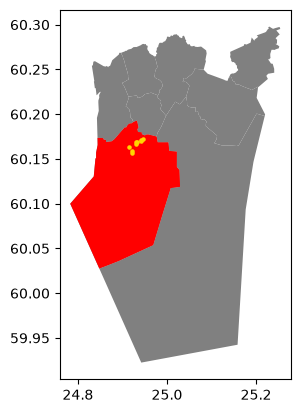

In [19]:
axes = city_districts.plot(facecolor="grey")
southern_district.plot(ax=axes, facecolor="red")

addresses_in_the_southern_district.plot(
    ax=axes,
    color="gold",
    markersize=5
)